<a href="https://colab.research.google.com/github/CieL7s/ReaL-ESRGAN-Colab/blob/main/upscalerr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# @title
# Clone Real-ESRGAN and enter the Real-ESRGAN
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
# Set up the environment
!pip install basicsr
!pip install facexlib
!pip install gfpgan
!pip install ffmpeg-python
!pip install -r requirements.txt
!python setup.py develop

from IPython.display import HTML
from base64 import b64encode

def show_video(video_path, video_width = 720):

  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video width={video_width} controls><source src="{video_url}"></video>""")

fatal: destination path 'Real-ESRGAN' already exists and is not an empty directory.
/content/Real-ESRGAN
/usr/local/lib/python3.12/dist-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running develop
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        sta

In [8]:
import os

# Define the path to the file
file_path = "/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py"

# Read the content of the file
with open(file_path, 'r') as file:
    file_data = file.readlines()

# Modify the specific line
for i, line in enumerate(file_data):
    if 'from torchvision.transforms.functional_tensor import rgb_to_grayscale' in line:
        file_data[i] = 'from torchvision.transforms.functional import rgb_to_grayscale\n'
        break

# Write the modified content back to the file
with open(file_path, 'w') as file:
    file.writelines(file_data)

print("Modification applied successfully.")


Modification applied successfully.


In [25]:
import os

source = "video" # @param ["image", "video"]
input = "/content/input.mp4" # @param {type:"string"}
model = "RealESRGAN_x4plus_anime_6B" # @param ["RealESRGAN_x4plus", "RealESRGAN_x2plus", "RealESRNet_x4plus", "official ESRGAN_x4", "realesr-general-x4v3", "RealESRGAN_x4plus_anime_6B", "realesr-animevideov3"]
scale = 2 # @param {type:"slider", min:1, max:4, step:1}
face_enhance = False # @param {type:"boolean"}

# Define the base directory for Real-ESRGAN scripts
REAL_ESRGAN_DIR = "/content/Real-ESRGAN"

if source=="image":
  script_name = "inference_realesrgan.py"
elif source =="video":
  script_name = "inference_realesrgan_video.py"

code = os.path.join(REAL_ESRGAN_DIR, script_name) # Construct the full path

def generate_output_path(input_path):
    # Get the directory from the input path
    directory, _ = os.path.split(input_path)

    return directory

def generate_result_path(input_path):
    # Extract the directory and filename from the input path
    directory, filename = os.path.split(input_path)

    # Remove the extension from the filename
    filename_without_extension, extension = os.path.splitext(filename)

    # Create the output path by adding '_out' before the extension
    output_filename = filename_without_extension + "_out" + extension
    output_path = os.path.join(directory, output_filename)

    return output_path

output = generate_output_path(input)
result = generate_result_path(input)
print(output)
print(result)
print(code)

/content
/content/input_out.mp4
/content/Real-ESRGAN/inference_realesrgan_video.py


In [26]:
if face_enhance == True:
  command = f"python '{code}' -i '{input}' -n '{model}' -o '{output}' -s '{scale}' --face_enhance"
elif face_enhance == False:
  command = f"python '{code}' -i '{input}' -n '{model}' -o '{output}' -s '{scale}'"
!{command}
# -h                   show this help
# -i input-path        input image path (jpg/png/webp) or directory
# -o output-path       output image path (jpg/png/webp) or directory
# -s scale             upscale ratio (can be 2, 3, 4. default=4)
# -t tile-size         tile size (>=32/0=auto, default=0) can be 0,0,0 for multi-gpu
# -m model-path        folder path to the pre-trained models. default=models
# -n model-name        model name (default=realesr-animevideov3, can be realesr-animevideov3 | realesrgan-x4plus | realesrgan-x4plus-anime | realesrnet-x4plus)
# -g gpu-id            gpu device to use (default=auto) can be 0,1,2 for multi-gpu
# -j load:proc:save    thread count for load/proc/save (default=1:2:2) can be 1:2,2,2:2 for multi-gpu
# -x                   enable tta mode"
# -f format            output image format (jpg/png/webp, default=ext/png)
# -v                   verbose output

inference: 100% 479/479 [08:45<00:00,  1.10s/frame]


In [ ]:
# input video
show_video(input)

In [ ]:
# enhanced video
show_video(result)

### Interactive Real-time Frame Comparison
Gunakan slider di bawah ini untuk memilih frame tertentu dan membandingkan hasilnya secara instan.

In [23]:
import base64
from IPython.display import HTML, display

def get_video_b64(path):
    video_file = open(path, "rb").read()
    return f"data:video/mp4;base64,{base64.b64encode(video_file).decode()}"

print("Loading videos and setting up real-time analytics...")
video_in_base64 = get_video_b64(input)
video_out_base64 = get_video_b64(result)

html_template = f"""
<div style='width: 100%; text-align: center; font-family: sans-serif; background: #f9f9f9; padding: 20px; border-radius: 10px;'>
    <div style='margin-bottom: 15px;'>
        <button onclick='playAll()' style='padding: 10px 25px; cursor: pointer; background: #4CAF50; color: white; border: none; border-radius: 5px;'>Play Both</button>
        <button onclick='pauseAll()' style='padding: 10px 25px; cursor: pointer; background: #f44336; color: white; border: none; border-radius: 5px;'>Pause Both</button>
    </div>

    <div style='display: flex; justify-content: space-around; gap: 20px;'>
        <!-- Original Video Section -->
        <div style='width: 48%; background: white; padding: 10px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);'>
            <p><b>Original Video</b></p>
            <video id='vIn' src='{video_in_base64}' style='width: 100%;' controls muted crossorigin='anonymous'></video>
            <canvas id='histIn' width='300' height='100' style='width: 100%; height: 80px; margin-top: 10px; border-top: 1px solid #eee;'></canvas>
            <p style='font-size: 0.8em; color: #888;'>Intensity Histogram</p>
        </div>

        <!-- Enhanced Video Section -->
        <div style='width: 48%; background: white; padding: 10px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);'>
            <p><b>Enhanced (Scale {scale})</b></p>
            <video id='vOut' src='{video_out_base64}' style='width: 100%;' controls crossorigin='anonymous'></video>
            <canvas id='histOut' width='300' height='100' style='width: 100%; height: 80px; margin-top: 10px; border-top: 1px solid #eee;'></canvas>
            <p style='font-size: 0.8em; color: #888;'>Intensity Histogram</p>
        </div>
    </div>
    <canvas id='hiddenCanvas' style='display:none;'></canvas>
</div>

<script>
    const vIn = document.getElementById('vIn');
    const vOut = document.getElementById('vOut');
    const canvas = document.getElementById('hiddenCanvas');
    const ctx = canvas.getContext('2d', {{alpha: false}});

    function playAll() {{ vIn.play(); vOut.play(); }}
    function pauseAll() {{ vIn.pause(); vOut.pause(); }}

    // Sync Logic
    vIn.onseeking = () => {{ vOut.currentTime = vIn.currentTime; }};
    vIn.onplay = () => vOut.play();
    vIn.onpause = () => vOut.pause();

    function drawHistogram(videoEl, canvasId, color) {{
        if (videoEl.paused || videoEl.ended) return;

        const targetCanvas = document.getElementById(canvasId);
        const tCtx = targetCanvas.getContext('2d');

        // Resize hidden canvas to video frame size
        canvas.width = 150;
        canvas.height = Math.floor(videoEl.videoHeight * (150 / videoEl.videoWidth));

        ctx.drawImage(videoEl, 0, 0, canvas.width, canvas.height);
        const frame = ctx.getImageData(0, 0, canvas.width, canvas.height);
        const data = frame.data;

        let hist = new Array(256).fill(0);
        for (let i = 0; i < data.length; i += 4) {{
            let avg = Math.floor((data[i] + data[i+1] + data[i+2]) / 3);
            hist[avg]++;
        }}

        let maxVal = Math.max(...hist);
        tCtx.clearRect(0, 0, targetCanvas.width, targetCanvas.height);
        tCtx.fillStyle = color;

        for (let i = 0; i < 256; i++) {{
            let h = (hist[i] / maxVal) * targetCanvas.height;
            tCtx.fillRect(i * (targetCanvas.width / 256), targetCanvas.height - h, 1, h);
        }}
    }}

    function updateGraphs() {{
        drawHistogram(vIn, 'histIn', '#2196F3');
        drawHistogram(vOut, 'histOut', '#4CAF50');
        requestAnimationFrame(updateGraphs);
    }}

    vIn.addEventListener('play', () => requestAnimationFrame(updateGraphs));
</script>
"""

display(HTML(html_template))

Loading videos and setting up real-time analytics...


### Detailed Video Analytics & Metric Comparison
Sel ini akan menganalisis metrik teknis antara video asli dan video hasil peningkatan, termasuk kecerahan, kontras, serta skor kualitas gambar (PSNR & SSIM).

Analyzing videos for technical details...


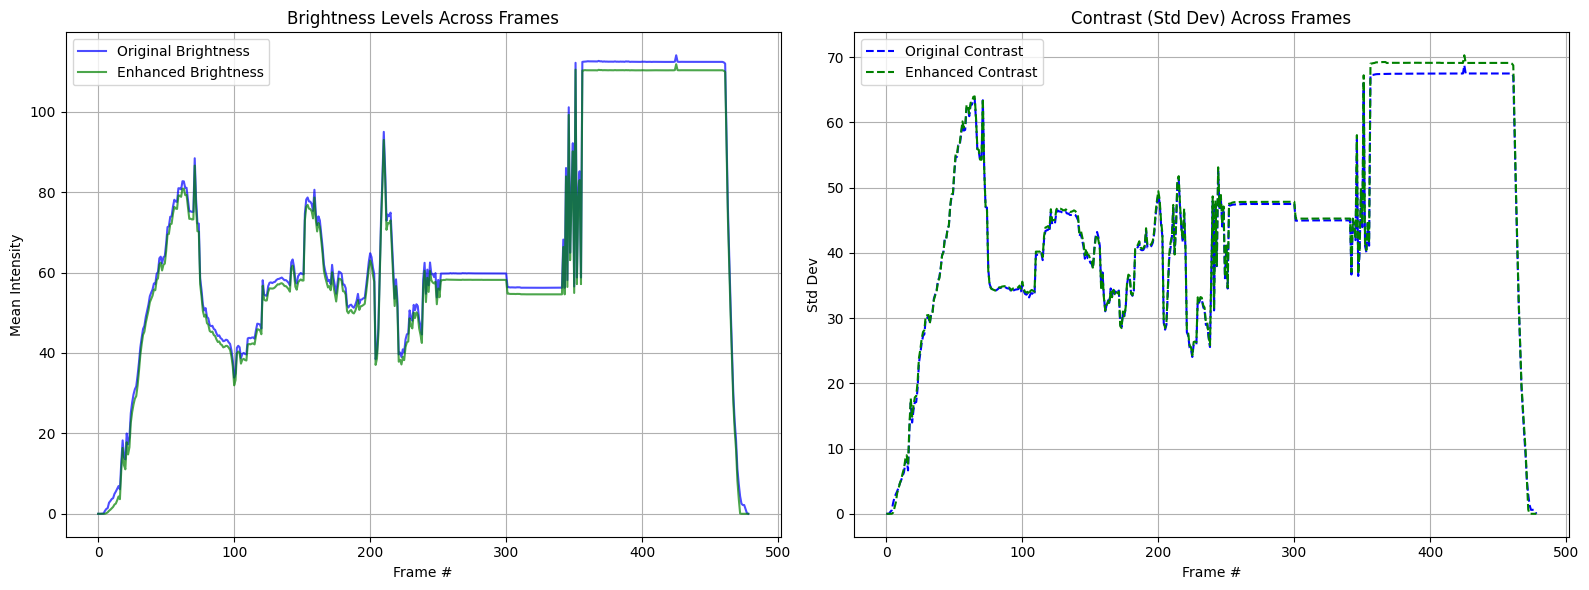


--- Technical Enhancement Summary ---
Peak Signal-to-Noise Ratio (PSNR): 361.20 dB
Structural Similarity Index (SSIM): 1.0000
Avg Brightness Delta: -1.80
Avg Contrast Improvement: 1.28%


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def analyze_video(path):
    cap = cv2.VideoCapture(path)
    brightness = []
    contrast = []
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret: break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))
        contrast.append(gray.std())
        if len(frames) < 1: # Keep first frame for comparison
            frames.append(gray)

    cap.release()
    return brightness, contrast, frames[0]

print("Analyzing videos for technical details...")
b_in, c_in, f_in = analyze_video(input)
b_out, c_out, f_out = analyze_video(result)

# Calculate Quality Metrics (using first frame as sample if dimensions match)
psnr_val = cv2.PSNR(f_in, cv2.resize(f_out, (f_in.shape[1], f_in.shape[0])))
ssim_val = ssim(f_in, cv2.resize(f_out, (f_in.shape[1], f_in.shape[0])))

# Plotting Details
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Brightness Comparison
ax1.plot(b_in, label='Original Brightness', color='blue', alpha=0.7)
ax1.plot(b_out, label='Enhanced Brightness', color='green', alpha=0.7)
ax1.set_title('Brightness Levels Across Frames')
ax1.set_xlabel('Frame #')
ax1.set_ylabel('Mean Intensity')
ax1.legend()
ax1.grid(True)

# Contrast Comparison
ax2.plot(c_in, label='Original Contrast', color='blue', linestyle='--')
ax2.plot(c_out, label='Enhanced Contrast', color='green', linestyle='--')
ax2.set_title('Contrast (Std Dev) Across Frames')
ax2.set_xlabel('Frame #')
ax2.set_ylabel('Std Dev')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\n--- Technical Enhancement Summary ---")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_val:.2f} dB")
print(f"Structural Similarity Index (SSIM): {ssim_val:.4f}")
print(f"Avg Brightness Delta: {np.mean(b_out) - np.mean(b_in):.2f}")
print(f"Avg Contrast Improvement: {((np.mean(c_out)/np.mean(c_in))-1)*100:.2f}%")

In [27]:
!pip install -q gradio

In [ ]:
import gradio as gr
import subprocess
import os

# Path repo Real-ESRGAN
REAL_ESRGAN_DIR = "/content/Real-ESRGAN"

def run_upscale(input_file, source_type, model, scale, face_enhance):
    if input_file is None:
        return None

    # Gunakan directory absolute
    directory = "/content/gradio_outputs"
    if not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)

    input_path = input_file
    filename = os.path.basename(input_path)
    name_no_ext, ext = os.path.splitext(filename)

    script_name = "inference_realesrgan.py" if source_type == "image" else "inference_realesrgan_video.py"
    code_path = os.path.join(REAL_ESRGAN_DIR, script_name)
    output_path = os.path.join(directory, f"{name_no_ext}_out{ext}")

    command = [
        "python", code_path,
        "-i", input_path,
        "-n", model,
        "-o", directory,
        "-s", str(int(scale))
    ]

    if face_enhance:
        command.append("--face_enhance")

    try:
        subprocess.run(command, check=True)
        return output_path
    except Exception as e:
        return f"Error: {str(e)}"

# --- Interface UI ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("## 🌌 Real-ESRGAN GUI")

    with gr.Row():
        with gr.Column():
            source_type = gr.Radio(["image", "video"], label="Tipe File", value="image")
            input_img = gr.Image(type="filepath", label="Input Image")
            input_vid = gr.Video(label="Input Video", visible=False)

            def update_input(choice):
                if choice == "video":
                    return gr.update(visible=False), gr.update(visible=True)
                return gr.update(visible=True), gr.update(visible=False)

            source_type.change(update_input, source_type, [input_img, input_vid])

            model_dropdown = gr.Dropdown(
                choices=["RealESRGAN_x4plus", "RealESRGAN_x2plus", "RealESRNet_x4plus", "realesr-general-x4v3", "RealESRGAN_x4plus_anime_6B", "realesr-animevideov3"],
                value="RealESRGAN_x4plus_anime_6B",
                label="Model"
            )
            scale_slider = gr.Slider(1, 4, value=2, step=1, label="Scale")
            face_enhance_check = gr.Checkbox(label="Face Enhance (GFPGAN)")
            btn = gr.Button("Process!", variant="primary")

        with gr.Column():
            output_display = gr.File(label="Download Hasil")

    def process_router(img, vid, stype, mdl, scl, face):
        target = img if stype == "image" else vid
        return run_upscale(target, stype, mdl, scl, face)

    btn.click(
        fn=process_router,
        inputs=[input_img, input_vid, source_type, model_dropdown, scale_slider, face_enhance_check],
        outputs=output_display
    )

# Mematikan queueing progress yang menyebabkan RuntimeError
demo.queue().launch(
    share=True,
    debug=True,
    allowed_paths=["/content/gradio_outputs"],
    max_threads=1
)

/tmp/ipykernel_4339/838017857.py:43: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1e85e4d94558686ff5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from IPython.display import Image, display

display(Image(filename=input, width=720))
display(Image(filename=result, width=720))